refer `D03`,`D06`

In [104]:
import crypy as cp
import numpy as np
from matplotlib import pyplot as plt
from crypy_examples.atom_network import (
    draw_atom, 
    draw_bond,
    color_bond,
    color_Se,
    color_Ta,
    r_Se,
    r_Ta,
    r_bond,
    a1,a2,
    p1,p2,p3,p4        
)
from crypy_examples.chiral_interlock import lattice_points_in_hex
from matplotlib.colors import to_rgb

# region Fundamental Parameters
xylim = ((-10,10),(-10,10))

In [105]:
color_Se_HA = [254,164,0]
color_Ta_HA = [0, 176, 240]
color_hollow = [255, 0, 150]
color_Se_vesta = [202,137,33]
color_Ta_vesta = [38,115,148]
hexer =  lambda rgb: '#{:02x}{:02x}{:02x}'.format(*rgb)

In [106]:
def draw_latt():
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    fig,ax  = cry.plot_crystal()
    # cry_sup.plot_crystal()
    ax.set_xlim(-4,4)
    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])

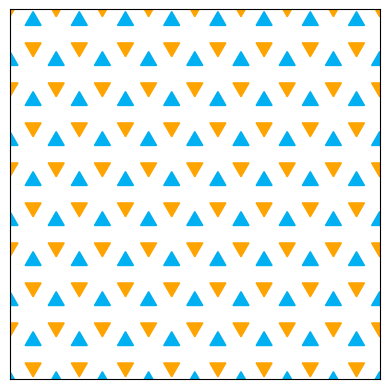

In [107]:
draw_latt()

In [108]:
def draw_center(pos_CDW,clr_CDW=color_hollow):
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    pv_sup = pv.get_super_structure(3,3)
    bss_sup = cp.Basis2D(pv_sup)
    def gen_CDW(x,y):    
        ec = np.array(clr_CDW)/255
        ec = np.append(ec,0.6)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=1,fc=(0,0,0,0),ec = ec,lw=3)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=.3,fc=(0,0,0,0),ec = ec,lw=3)
    bss_sup.add_artist(gen_CDW,pos_CDW,label='CDW')
    lp_sup = cp.LatticePoints2D(pv_sup)   
    lp_sup.generate_points_by_xylim(*xylim)
    cry_sup = cp.Crystal2D(bss_sup,lp_sup)
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    # fig,ax  = cry.plot_crystal()
    fig,ax = cry_sup.plot_crystal()
    ax.set_xlim(-4,4)

    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])

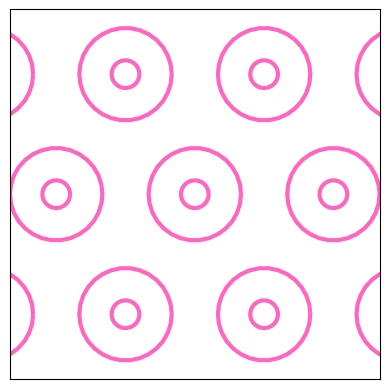

In [109]:
draw_center(np.array([0,0]))

In [110]:
def from_phi123_to_n12t(phi123):
    """transformation from (phi1,phi2,phi3) to (n1,n2,t)
    Args:
        phi123: 3tuple,list,array
    Returns:
        n12t: 3 array
    Raises:
    """
    phi123 = np.array(phi123) # here phi123 should be (3,)
    phi123_ = phi123 - np.array([1,0,0])
    
    T = np.array([
    [0,-1,1],[1,0,1],[-1,1,1]
    ])
    T_inv = np.linalg.inv(T)
    n12t = T_inv@phi123_
    return n12t

In [111]:
from_phi123_to_n12t([0,0,0])

array([ 0.33333333,  0.66666667, -0.33333333])

In [112]:
color_hollow

[255, 0, 150]

In [113]:
def draw_k(phis,ax):
    c = np.array(color_hollow)/255
    c = np.append(c,0.3)
    ccc =(c,c,c)
    O = np.array((0,1/(np.sqrt(3))))
    ks = np.array(((0,1),(-np.sqrt(3)/2, -1/2),(np.sqrt(3)/2, -1/2)))
    ks = ks*(2/(3*np.sqrt(3)))
    for k,ik in zip(ks[:3],range(3)):
        k_abs = np.linalg.vector_norm(k)
        d = k/(k_abs**2)
        cp.Collection.plot_plane_wave_lines(
            k=k, color=ccc, ax=ax,
            origin=O+d*phis[ik]*(2/3),
            lw = 4)
        cp.Collection.plot_plane_wave_lines(
            k=k*3, color=ccc, ax=ax,
            origin=O+d*phis[ik]*(2/3),
            lw = 2)        

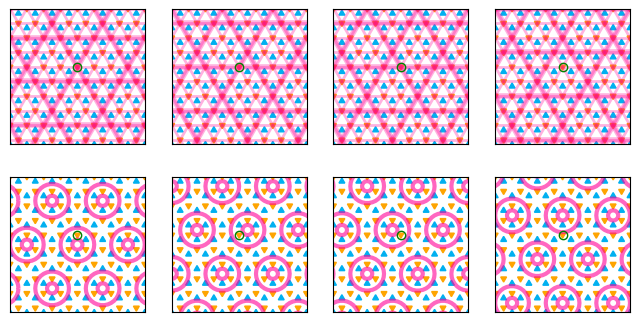

In [114]:
O = np.array((0,1/(np.sqrt(3))))
phiss = [
    [1,0,0],
    [0,1,0],
    [0,0,1],
    [-1,1,1]
]
n1n2s = list(map(from_phi123_to_n12t,phiss))
msb,nsb = 2,4
fig,axs = plt.subplots(msb,nsb,figsize=(8,4))
for isb in range(msb):
    for jsb in range(nsb):
        phis = phiss[jsb]
        n1n2=n1n2s[jsb
        ]
        ax = axs[isb,jsb]
        plt.sca(ax)
        # draw(pos_CDW=p2/3+np.array(n1n2),clr_CDW=color_hollow)
        # draw2(phis,n1n2[:-1],ax=ax)
        draw_latt()
        if isb == 1:
            draw_center(pos_CDW=n1n2[:-1]/3)
        elif isb == 0:
            draw_k(phis=phis,ax=ax)
        plt.plot(O[0],O[1],'go',markerfacecolor='none')
fig.savefig('assets/E02_v4.svg')


In [115]:
def draw_center(pos_CDW,clr_CDW=color_hollow,mul=3,r = .3):
    def gen_CDW(x,y):    
        ec = np.array(clr_CDW)/255
        ec = np.append(ec,0.6)
        # cp.Collection.Generator.gen_regular_polygon(
        # 30,x=x,y=y,r=1,fc=(0,0,0,0),ec = ec,lw=3)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=r,fc=(0,0,0,0),ec = ec,lw=3)
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    pv_sup = pv.get_super_structure(mul,mul)
    bss_sup = cp.Basis2D(pv_sup)    
    bss_sup.add_artist(gen_CDW,pos_CDW,label='CDW')
    lp_sup = cp.LatticePoints2D(pv_sup)   
    lp_sup.generate_points_by_xylim(*xylim)
    cry_sup = cp.Crystal2D(bss_sup,lp_sup)
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    # fig,ax  = cry.plot_crystal()
    fig,ax = cry_sup.plot_crystal()
    ax.set_xlim(-4,4)

    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])

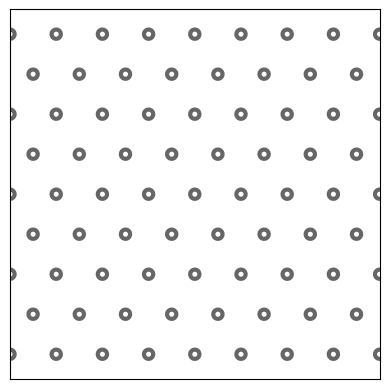

In [116]:
draw_center(np.array([0,0]),mul=1,r=.1,clr_CDW=[0,0,0])

In [117]:
def draw_k(phis,ax):
    c = np.array(color_hollow)/255
    c = np.append(c,0.3)
    ccc =(c,c,c)
    O = np.array((0,1/(np.sqrt(3))))
    ks = np.array(((0,1),(-np.sqrt(3)/2, -1/2),(np.sqrt(3)/2, -1/2)))
    ks = ks*(2/(3*np.sqrt(3)))
    for k,ik in zip(ks[:3],range(3)):
        k_abs = np.linalg.vector_norm(k)
        d = k/(k_abs**2)
        cp.Collection.plot_plane_wave_lines(
            k=k*3, color=["k","k","k"], ax=ax,
            origin=O+d*phis[ik]*(2/3),
            lw = .5)
        cp.Collection.plot_plane_wave_lines(
            k=k, color=ccc, ax=ax,
            origin=O+d*phis[ik]*(2/3),
            lw = 4)
              

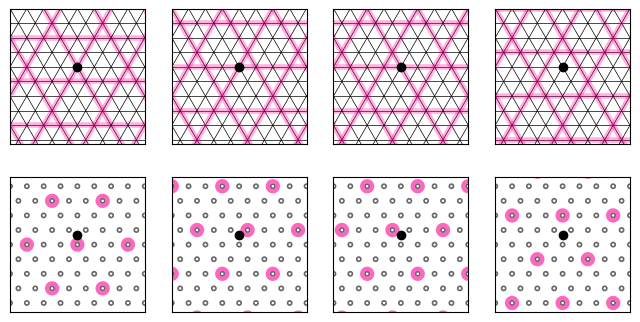

In [126]:
O = np.array((0,1/(np.sqrt(3))))
phiss = [
    [1,0,0],
    [0,1,0],
    [0,0,1],
    [-1,1,1]
]
n1n2s = list(map(from_phi123_to_n12t,phiss))
msb,nsb = 2,4
fig,axs = plt.subplots(msb,nsb,figsize=(8,4))
for isb in range(msb):
    for jsb in range(nsb):
        phis = phiss[jsb]
        n1n2=n1n2s[jsb
        ]
        ax = axs[isb,jsb]
        plt.sca(ax)
        # draw(pos_CDW=p2/3+np.array(n1n2),clr_CDW=color_hollow)
        # draw2(phis,n1n2[:-1],ax=ax)
        # draw_latt()
        ax.set_xlim(-4,4)
        ax.set_ylim(-4,4)
        ax.set_xticks([])
        ax.set_yticks([])
        if isb == 1:
            
            draw_center(pos_CDW=n1n2[:-1],mul=1,r=.05,clr_CDW=[0,0,0])
            draw_center(pos_CDW=n1n2[:-1]/3)
        elif isb == 0:
            draw_k(phis=phis,ax=ax)
            # draw_center(pos_CDW=n1n2[:-1],mul=1,r=.05,clr_CDW=[0,0,0])
        plt.plot(O[0],O[1],'ko')
fig.savefig('assets/E02_v5.svg')


In [119]:
color_hollow

[255, 0, 150]